# Løsningsforslag – øvingsoppgaver 3 – Regresjon
*Data Mining & Analytics – Samling 2, dag 2 (formiddag)*

Datasett: `diamonds_5000` – 5 000 diamanter med pris (USD) og egenskaper: `carat` (vekt), `cut`, `color`, `clarity` (kvalitet), `depth`, `table`, samt dimensjonene `x`, `y`, `z`.
**Mål: predikere `price`.** Bruk kodeeksemplene fra forelesningen (notebook 01–04). Jobb i par.

In [7]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(1)
dia = pd.read_csv("../Data/diamonds_5000.csv")
dia.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


### Oppgave 1 – Utforsk
- a) Plott fordelingen av `price` (histogram). Vurder om det kan være lurt å logtransformere  price`?
- b) Lag et scatterplott av carat mot `price`, og av log(carat) mot `log(price)`. Hva ser du?
- c) Lag en korrelasjonsmatrise for de numeriske variablene. Er det noen variabler som er redundante?

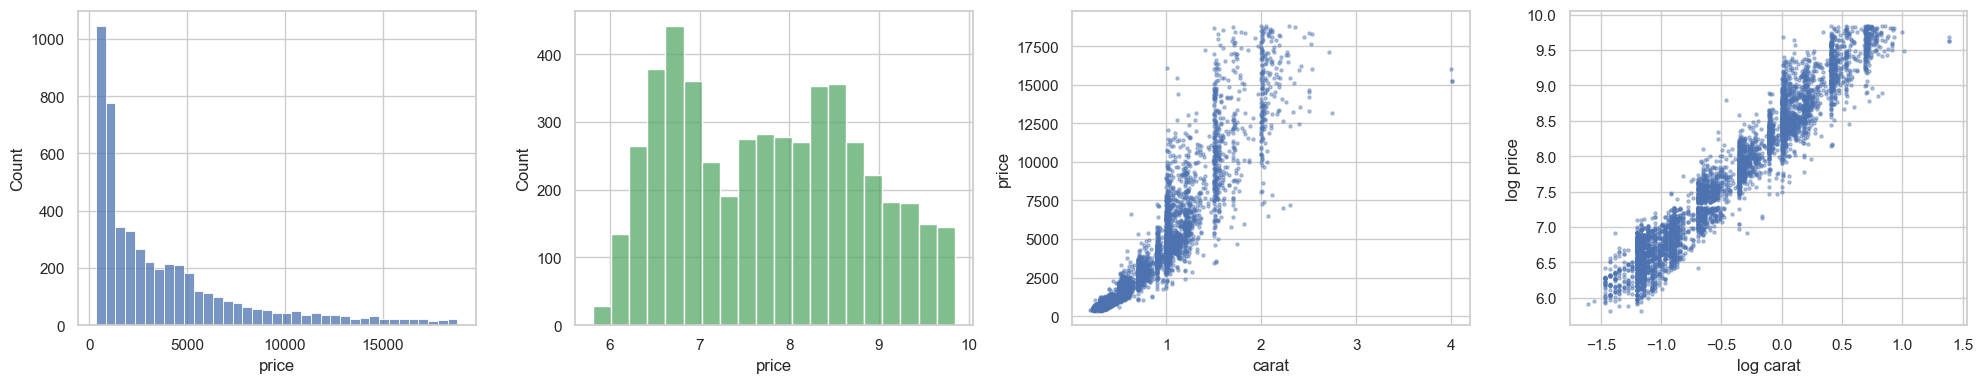

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))

sns.histplot(dia["price"], ax=ax[0])
sns.histplot(np.log(dia["price"]), ax=ax[1], color="C2")

ax[2].scatter(dia["carat"], dia["price"], s=5, alpha=0.4)
ax[2].set_xlabel("carat")
ax[2].set_ylabel("price")
ax[3].scatter(np.log(dia["carat"]), np.log(dia["price"]), s=5, alpha=0.4) 
ax[3].set_xlabel("log carat")
ax[3].set_ylabel("log price")
plt.tight_layout() 
plt.show()

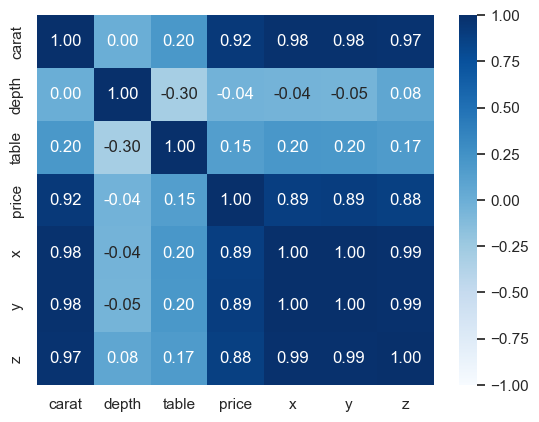

In [11]:
sns.heatmap(dia.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.show()

**Løsningsforslag – svar:**


Prisen er sterkt høyreskjev. Log-transformasjon gjør den mer symmetrisk og gjør sammenhengen med karat nesten lineær i det logaritmiske rommet. 

 carat, x, y, z er nesten perfekt korrelert (r > 0,95) – diamantens dimensjoner er i praksis en funksjon av vekten og dette gir hva vi kaller multikollinearitet (høy grad av redundans) hvis alle variabler tas med. 

### Oppgave 2 – Del dataene og lag en baseline

Del i trening (80 %) og test (20 %) med random_state=0. Beregn RMSE, MAE og R2 på testsettet for en baseline-modell (dummy) som alltid gjetter gjennomsnittet av treningsprisene.

In [12]:
y = dia["price"]
X = dia.drop(columns="price")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

def rapport(y_sann, y_pred, navn=""):
    rmse = np.sqrt(mean_squared_error(y_sann, y_pred))
    mae = mean_absolute_error(y_sann, y_pred)
    print(f"{navn:28s} RMSE = {rmse:8.0f}  MAE = {mae:8.0f}  R^2 = {r2_score(y_sann, y_pred):.3f}  MAE/snittpris = {mae / y_sann.mean():.1%}")

base = DummyRegressor().fit(X_train, y_train)
rapport(y_test, base.predict(X_test), "Baseline (gjennomsnitt)")

Baseline (gjennomsnitt)      RMSE =     4060  MAE =     3079  R^2 = -0.000  MAE/snittpris = 77.6%


**Løsningsforslag – svar:**


Baseline gir RMSE ca lik 4 000 USD og R2 ca lik 0 (som forventet mtp estimering basert på gjennomsnitt). Dette er tallet alle modeller bør slå.

### Oppgave 3 – Lineær regresjon: original vs. logaritmisk skala
- a) Tren LinearRegression på de numeriske variablene  for å predikere `price`. Rapporter testmetrikker.
- b) Tren samme modell for å log-normlisere skjevfordelte variabler (også target). Regn prediksjonene tilbake med np.exp og rapporter RMSE/MAE i USD.
- c) Hvilken metode er best? 

In [ ]:
num = ["carat", "depth", "table", "x", "y", "z"]
lr = LinearRegression().fit(X_train[num], y_train)
rapport(y_test, lr.predict(X_test[num]), "Lineær (6 numeriske)") # bruker funksjonen fra forrige oppgave

lr_log = LinearRegression().fit(np.log(X_train[["carat"]]), np.log(y_train))
pred_log = np.exp(lr_log.predict(np.log(X_test[["carat"]]))) #transformerer tilbake etter estimering
rapport(y_test, pred_log, "log(pris) ~ log(carat)")

Lineær (6 numeriske)         RMSE =     1570  MAE =      911  R² = 0.850  MAE/snittpris = 23.0%
log(pris) ~ log(carat)       RMSE =     1859  MAE =      867  R² = 0.790  MAE/snittpris = 21.9%


Logaritmisk med en variabel gir litt lavere MAE (bedre på de typiske, billigere diamantene) men høyere RMSE (dårligere på de få dyre, der en prosentfeil gir store utslag i pris). Valg av metrikk påvirker hvilken modell som er best.